In [1]:
from AIce.models import linear
from AIce.functions import torchRMSE,trainloader,testloader,redim,getRMSE
from torch import optim

import numpy as np
import torch
import matplotlib.pyplot as plt

from time import strftime
# [['u_ERA5','v_ERA5','h_piomas','sic_CDR','x_EASE','y_EASE','bath','sin','cos', 'windnorm'],
#             ['u_ERA5','v_ERA5','h_piomas','sic_CDR','x_EASE','y_EASE','bath','sin','cos'],
#             ['u_ERA5','v_ERA5','h_piomas','sic_CDR','x_EASE','y_EASE','bath'],
#             ['u_ERA5','v_ERA5','h_piomas','sic_CDR','x_EASE','y_EASE'],
#             ['u_ERA5','v_ERA5','h_piomas','sic_CDR'],
#             ['u_ERA5','v_ERA5','h_piomas','sic_CDR', 'windnorm'],
#             ['u_ERA5','v_ERA5','h_piomas'],
#             ['u_ERA5','v_ERA5']]
device='cuda'

In [3]:
inputlist=['u_ERA5','v_ERA5','h_piomas','sic_CDR','x_EASE','y_EASE','bath','sin','cos', 'windnorm']
lr =1e-3
n_epoch=20



# _,_,dataloader,_,_,_,labels=trainloader('../data/DRIFT_DATA_TRAIN.csv',256,inputlist=inputlist,target='buoynorm',)
# mlp256=linear(len(labels[1])).to(device)


# print('Total Epoch: ', n_epoch)
# print('Learning Rate: ', lr)
# print(labels)

# rlosses={}
# losses=[]
# rloss=0
# rcount=0

# optimizer = optim.Adam(mlp256.parameters(),lr=lr) # optimizers

# for epoch in range(n_epoch):
#     print('Starting Epoch ',epoch)
#     curpercent=0
#     rl=[]
#     for i,data in enumerate(dataloader):

#         # get the inputs and the target
#         truth,inputs= data[0].to(device),data[1].to(device)

#         # zero the gradients,
#         optimizer.zero_grad()

#         # Forward,
#         out=mlp256(inputs)


#         loss = torchRMSE(target=truth, outputs=out)
#         # Backward
#         loss.backward()
#         losses.append(loss.item())
#         # Optimize

#         optimizer.step()

#         rloss+= loss.item()
#         rcount +=1
#         #print where we at plus the loss
#         percent= round(i/len(dataloader)*100)
#         if percent != curpercent:
#         #    print(percent, 'loss: ', rloss/rcount)
#             curpercent=percent
#             rl.append(rloss/rcount)
#             rloss=0
#             rcount=0
#     rlosses[epoch]=rl
#     print('Epoch avg loss: ', np.mean(rl))

# saving_name=f'linear_{len(labels[1])}inputs_{n_epoch}E_{lr}lr_{strftime("%d-%Hh_%Mm_%Ss")}'

# torch.save(mlp256.state_dict(), f'.//weights//{saving_name}.pt')

# with open(f'.//weights//{saving_name}.txt','w') as f:
#     f.write(f'Model: linear (on gpu)\n')
#     f.write(f'Weights: {saving_name}.pt\n')
#     f.write(f'Associated inputs: {inputlist}')

# fig,ax =plt.subplots()
# epochavg=[]

# for i in (rlosses):
#     x=np.arange(i*len(rlosses[0]),len(rlosses[0])+i*len(rlosses[0]))
#     ax.plot(x,rlosses[i])#,label=f'Epoch {i+1}, lr={lr[i]:.1e}')
#     avg=np.mean(rlosses[i])
#     epochavg.append(avg)
# xx=[i*len(rlosses[0]) for i in rlosses]
# ax.plot(xx,epochavg,'.-k')
# plt.savefig(f'.//outputs//loss_for_{saving_name}.png')
# plt.close('all')

Bath size is the full test set
Target is buoynorm normalized by log1p
Sin and Cos added
Bathymetry (bath) normalized by maximum
x/y (x_EASE, y_EASE) normalized by maximum
Windnorm normalized by z-score
Wind components (u/v_ERA5) normalized by z-score
Wind components (u/v_ERA5) normalized by z-score
RMSE:  6.085587412713388


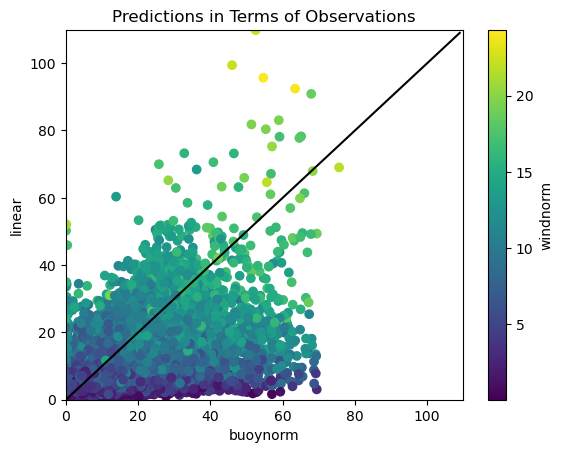

linear


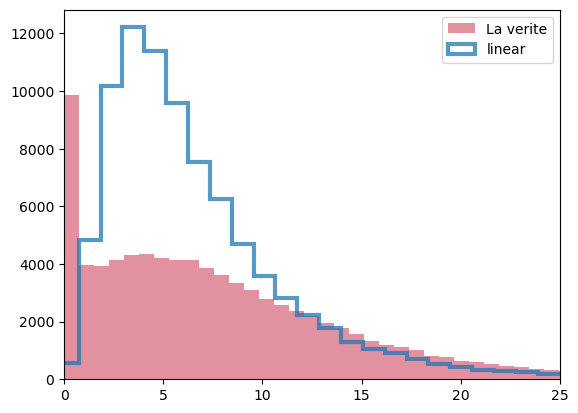

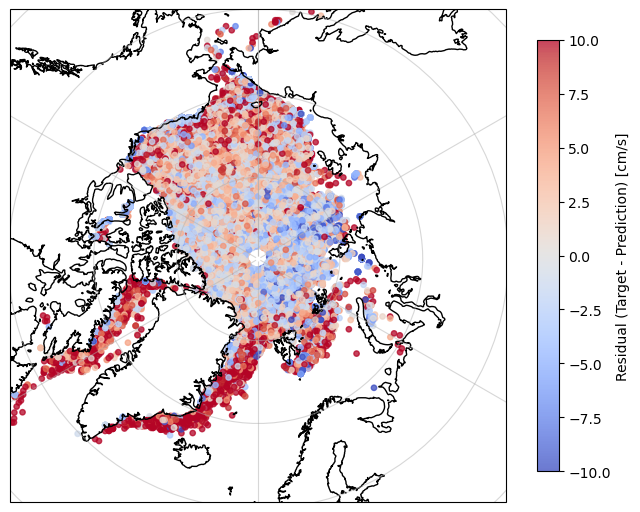

In [6]:
testdata,_,_,means,stds,maxes,_=testloader('../data/DRIFT_DATA_TEST.csv',inputlist
                                    ,'buoynorm',trainingset_loaded=False, training_file='../data/DRIFT_DATA_TRAIN.csv')# Get the means,stds,maxes using the longest list possible
linearmodel= linear(len(inputlist))
linearmodel.load_state_dict(torch.load('./weights/linear_10inputs_20E_0.001lr_09-17h_11m_05s.pt', weights_only= True))
linearmodel.eval()

out=linearmodel(torch.tensor(testdata.drop(['buoynorm'],axis=1).values, dtype= torch.float32))
testdata=redim(testdata,
               means=means,
               stds=stds,
               maxes=maxes)

testdata['linear']=np.expm1(out.detach().numpy())



rmse=getRMSE(testdata['buoynorm'].values, testdata['linear'].values)

print('RMSE: ', rmse)
from AIce.plotting import ResidualOnTheMap,PredAgainstTarget,histogrammeur

PredAgainstTarget(testdata['buoynorm'],testdata['linear'],testdata['windnorm'])
histogrammeur(testdata,testdata['buoynorm'],['linear'])
ResidualOnTheMap(testdata,pred='linear',target='buoynorm')
